In [3]:
import torch 
import numpy as np 
import h5py
import os
import IPython.display as ipd
from corpus.speaker_room_dataset import SpeakerRoomDataset
import src.audio_transforms as at

import src.spatial_attn_lightning as binaural_lightning 
import yaml
from tqdm.auto import tqdm

%matplotlib inline
import matplotlib.pyplot as plt

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

torch.set_float32_matmul_precision('medium')
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [4]:
!hostname

node082


### Approach for time shift - paramaterize phase shift 

In [5]:
### Get most recent config
# config_path = "config/binaural_attn/word_task_25p_loc_v07_LN_last_valid_time_no_affine.yaml"
# ckpt_path = "attn_cue_models/word_task_25p_loc_v07_LN_last_valid_time_no_affine/checkpoints/epoch=3-step=49432.ckpt"
# old_style = False
### Get most recent config
config_path = "config/binaural_attn/word_task_half_co_loc_v07.yaml"
ckpt_path = "attn_cue_models/word_task_half_co_loc_v07/checkpoints/epoch=2-step=46074.ckpt"
# old_style = True 

config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

config['hparas']['batch_size'] = 2 # config['data']['loader']['batch_size'] // args.gpus
config['num_workers'] = 2
config['noise_kwargs']['low_snr'] = 0
config['noise_kwargs']['high_snr'] = 0
# get model input sr for brir resampling
signal_sr = config['audio']['rep_kwargs']['sr']
coch_sr = config['audio']['rep_kwargs']['env_sr']
# cue_duration = 0.5
# n_cue_frames = int(cue_duration * signal_sr)
# config['model']['n_cue_frames'] = n_cue_frames

# config['cue_duration_test'] = True


In [6]:
model = binaural_lightning.BinauralAttentionModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config).cuda().eval()


num_classes={'num_words': 800}


/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torchaudio/functional/functional.py:1371: UserWarning: "kaiser_window" resampling method name is being deprecated and replaced by "sinc_interp_kaiser" in the next release. The default behavior remains unchanged.
  warnings.warn(


center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


In [7]:
dataset = SpeakerRoomDataset(manifest_path='/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl',
                            excerpt_path='/om2/user/msaddler/spatial_audio_pipeline/assets/swc/manifest_all_words.pdpkl',
                            cue_type='voice_and_location',
                            sr=signal_sr) 


diotic_transforms = at.AudioCompose([
                    at.AudioToTensor(),
                    at.CombineWithRandomDBSNR(low_snr=0, high_snr=0), 
                    at.RMSNormalizeForegroundAndBackground(rms_level=0.02),  # 0.02 is the default for CV-based models 
                    at.DuplicateChannel(),
            ])
copy_channel_and_norm = at.AudioCompose([
                    at.AudioToTensor(),
                    at.DuplicateChannel(),
                    at.BinauralRMSNormalizeForegroundAndBackground(rms_level=0.02, v2_demean=True)
            ])
rms_norm =  at.BinauralRMSNormalizeForegroundAndBackground(rms_level=0.02, v2_demean=True)

diotic_transforms = diotic_transforms.cuda()


## Define alternate audio transforms to see effect on generated distractors

In [8]:
standard_audio_transforms = at.AudioCompose([
                at.AudioToTensor(),
                at.BinauralCombineWithRandomDBSNR(low_snr=0,
                                                  high_snr=0,
                                                  v2_demean=True),
                at.BinauralRMSNormalizeForegroundAndBackground(rms_level=0.02, v2_demean=True), # 20 * np.log10(0.02/20e-6) = 60 dB SPL 
            ])


In [9]:
import pickle
class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
ix_to_word = {v: k for k, v in class_map.items()}

## Time-shift distractor optimization 

Will paramaterize phase shift of signal, done in frequency domain

In [10]:
class TimeShift(torch.nn.Module):
    def __init__(self, samplerate, epsilon=1e-4):
        super(TimeShift, self).__init__()
        self.t = torch.nn.Parameter(torch.tensor(0.0))  # initialize delay as a learnable parameter
        self.samplerate = samplerate
        self.epsilon = epsilon

    def forward(self, distractor):
        # Convert delay from seconds to samples
        t_samples = self.t * self.samplerate
        # Take the Fourier transform of the signal
        distractor_fft = torch.fft.fft(distractor)
        # Create a phase shift
        phase_shift = torch.exp(-2j * np.pi * t_samples * torch.fft.fftfreq(distractor.shape[0], device=t_samples.device))
        # Apply the phase shift and take the inverse Fourier transform
        shifted_signal = torch.fft.ifft(distractor_fft * phase_shift).real
        return shifted_signal


class CenterCrop(torch.nn.Module):
    def __init__(self, crop_size):
        super(CenterCrop, self).__init__()
        self.crop_size = crop_size

    def forward(self, x):
        start = (x.shape[-1] - self.crop_size) // 2
        return x[..., start:start+self.crop_size]

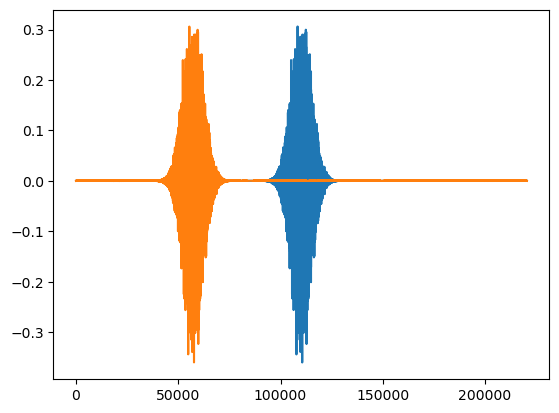

In [11]:
SAMPLERATE= 44_100
noise_len = 5
## init distractor signal as 10 second chunk
distractor = torch.randn((int(SAMPLERATE * noise_len)), device='cuda') 

Q = 100 
# apply cosine window to signal 
cos_window = torch.hann_window(int(SAMPLERATE * noise_len), periodic=False).cuda()
# apply modulate 
distractor = distractor * cos_window**Q
distractor = rms_norm(distractor.unsqueeze(0), None)[0].squeeze()



# Convert delay from seconds to samples
t = -1.2  # delay in seconds
t = t * SAMPLERATE  # convert delay to samples


# Get the duration of the non-zero part of the signal
non_zero_signal = distractor[torch.abs(distractor) > 1e-4]
non_zero_duration = non_zero_signal.shape[0]

# Check that the delay is less than half the length of the signal minus half the duration of the non-zero part
if abs(t) > (distractor.shape[0] - non_zero_duration) / 2:
    print("The delay must be less than half the length of the signal minus half the duration of the non-zero part.")
    t = np.sign(t) * (distractor.shape[0] - non_zero_duration) / 2

# Take the Fourier transform of the signal
distractor_fft = torch.fft.fft(distractor)

# Create a phase shift
phase_shift = torch.exp(-2j * np.pi * t * torch.fft.fftfreq(distractor.shape[0])).cuda()

# Apply the phase shift and take the inverse Fourier transform
shifted_signal = torch.fft.ifft(distractor_fft * phase_shift).real

# Plot the signals
plt.plot(distractor.cpu().numpy())
plt.plot(shifted_signal.real.cpu().numpy())  

# Display the audio
ipd.display(ipd.Audio(distractor.cpu().numpy(), rate=SAMPLERATE, normalize=False))
ipd.display(ipd.Audio(shifted_signal.real.cpu().numpy(), rate=SAMPLERATE, normalize=False))

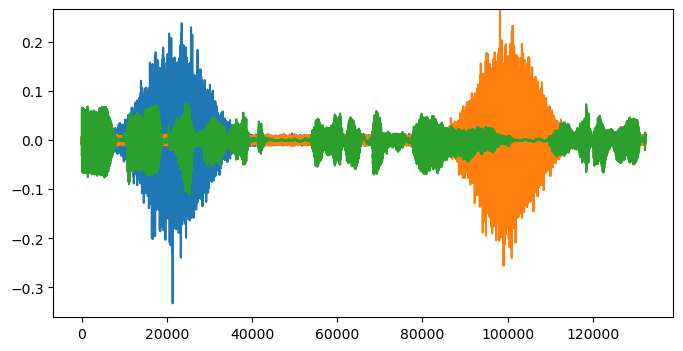

 11%|█▏        | 114/1000 [00:44<05:48,  2.54it/s, Best loss: -7.9963 Current loss: -0.0106 Early stop: 906 Time-delay Param: 1.7576 Grad -1.0000]     


KeyboardInterrupt: 

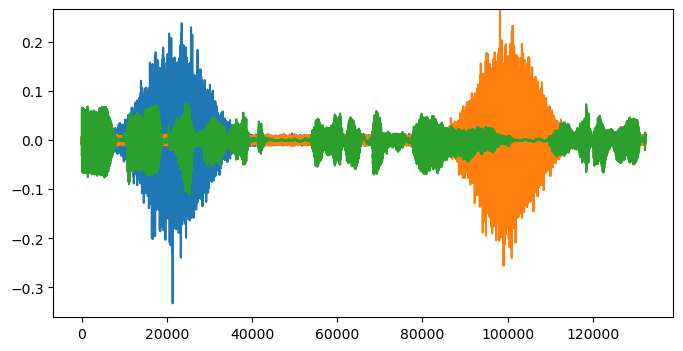

In [27]:
## dev dummy signal optimization proceedure - will most likely yeild adversarial example 
# from torch.optim.lr_scheduler import OneCycleLR

RANDOMSEED=0
EARLYSTOP = 1000
SAMPLERATE= 44_100

win_size_s = .1
signal_len = 3 # in seconds
noise_len = 3 # in seconds 
noise_eps=5e-2 # noise floor used in distractor signal


torch.manual_seed(RANDOMSEED)
np.random.seed(RANDOMSEED)

audio_transforms = standard_audio_transforms.cuda()
coch_transform = model.coch_gram.cuda()

## init distractor signal
distractor = torch.randn((int(SAMPLERATE * noise_len)), device='cuda') 
Q = 20
# apply cosine window to signal to make middle peak
cos_window = torch.hann_window(int(SAMPLERATE * noise_len), periodic=False).cuda()
# apply modulate 
distractor = distractor * cos_window**Q #  q shapes slope at peak

## add low level noise so min in signal still has power 
distractor = distractor +  torch.randn_like(distractor) * noise_eps

distractor = rms_norm(distractor.unsqueeze(0), None)[0].squeeze()
## manually shift the middle point of the distractor signal back by one second 
distractor = torch.roll(distractor, int(SAMPLERATE * -1))

ix = 10
cue, fg, bg, label, confusion = dataset[ix]
# _, _, bg2, _, confusion2 = dataset[ix+1]

# bg_, bg2_ = rms_norm(bg.unsqueeze(0), bg2.unsqueeze(0))
# full_bg = torch.cat([bg_, bg2_],axis=1).squeeze()


cue, _ = diotic_transforms(cue, None)
fg, _ = diotic_transforms(fg, None)
# bg, _ = diotic_transforms(distractor, None )
# full_bg, _ = diotic_transforms(full_bg, None)

# push to gpu 
cue = cue.cuda().unsqueeze(0)
fg = fg.cuda().unsqueeze(0)
bg = bg.cuda().unsqueeze(0)
# full_bg = full_bg.cuda().unsqueeze(0)
label = torch.tensor(label).unsqueeze(0).cuda() 

time_shift = TimeShift(SAMPLERATE).cuda()
time_delay_param = time_shift.t
# get noise clamp limit 
non_zero_duration = distractor[torch.abs(distractor) > noise_eps].shape[0]
clamp_lim = ((distractor.shape[0] - non_zero_duration) / 2) // SAMPLERATE

# 
# crop_op = CenterCrop(fg.shape[-1])

optimizer = torch.optim.Adam(
            time_shift.parameters(), #weighted_fft.weights],
            lr=0.1,
            # momentum=0.9,
            # weight_decay=5e-4,
        )

loss_fn =  torch.nn.CrossEntropyLoss()

n_steps = 1000

# target_word = torch.tensor([450]).cuda()

best_loss = 1.0
best_distractor = None
best_step = 0 
early_stop = EARLYSTOP

cue_cg, _ = coch_transform(cue, None)

## init plot with target and distractor positions 

fig, axs = plt.subplots(1, 1, figsize=(8, 4))
axs.plot(distractor.cpu().numpy())
dist_line, = axs.plot(distractor.cpu().numpy())
axs.plot(fg.cpu().numpy().squeeze()[0])

display = ipd.display("", display_id=True)

for step in (pbar := tqdm(range(n_steps))):
    optimizer.zero_grad()

    distractor_eg = time_shift(distractor)
    # distractor_eg_crop = crop_op(distractor_eg)
    distractor_eg_fin, _ = copy_channel_and_norm(distractor_eg, None )
    # center crop to dur of fg

    # make rms equal in windows for distractor
    mixture_wav, _ = audio_transforms(fg, distractor_eg_fin)
    mixture, _ = coch_transform(mixture_wav, None)

    logits = model(cue_cg, mixture, None)
    loss = -loss_fn(logits, label) # -  (10 * corr) 

    loss.backward()
    torch.nn.utils.clip_grad_norm_(time_shift.parameters(), 1.0, foreach=True)
# 
    optimizer.step()
    # break
    # get time param for print statement 

    if loss < best_loss:
        best_loss = loss.detach().item()
        # print(f"best loss {best_loss.detach().item():.3f} on step {step}")
        best_distractor = distractor_eg.detach()
        best_step = step 
        early_stop = EARLYSTOP
        pbar.set_postfix_str(f"New Best loss: {best_loss:.4f} Current loss: {loss.detach().item():.4f} Early stop: {early_stop}  Time-delay Param: {time_delay_param.item():.4f} Grad {time_delay_param.grad.item():.4f}")#HP energy: {hp_energy.detach().item():.3f}")

    else:
        early_stop -= 1 

    # if step % 100 == 0: 
    pbar.set_postfix_str(f"Best loss: {best_loss:.4f} Current loss: {loss.detach().item():.4f} Early stop: {early_stop} Time-delay Param: {time_delay_param.item():.4f} Grad {time_delay_param.grad.item():.4f}")

    # update plot
    dist_line.set_ydata(distractor_eg.detach().squeeze().cpu().numpy())
    display.update(fig)

    if early_stop == 0:
        break 

    # clamp to prevent circular time shifts
    # time_shift.t.data = time_shift.t.data.clamp(min=-clamp_lim, max=clamp_lim)
    # break



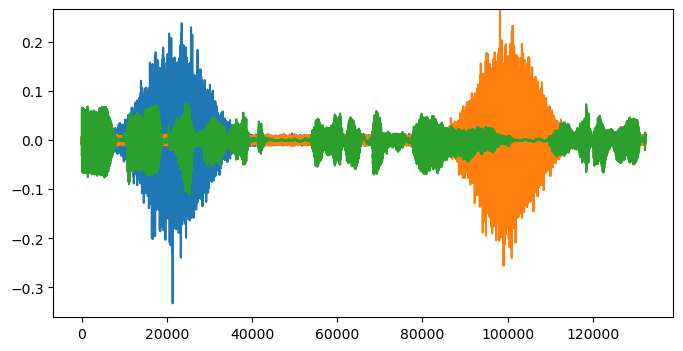

 11%|█▏        | 114/1000 [00:44<05:48,  2.54it/s, Best loss: -7.9963 Current loss: -0.0106 Early stop: 906 Time-delay Param: 1.7576 Grad -1.0000]     


KeyboardInterrupt: 

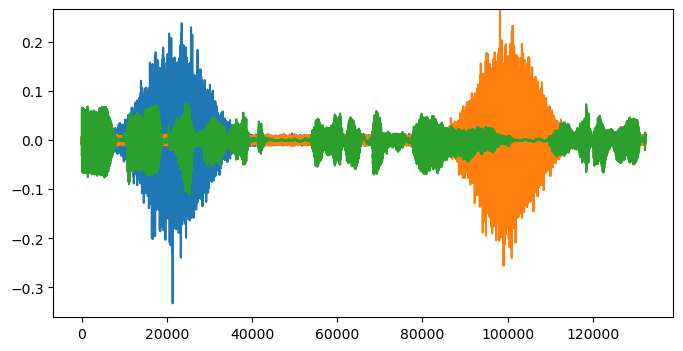

In [ ]:
## dev dummy signal optimization proceedure - will most likely yeild adversarial example 
# from torch.optim.lr_scheduler import OneCycleLR

RANDOMSEED=0
EARLYSTOP = 1000
SAMPLERATE= 44_100

win_size_s = .1
signal_len = 3 # in seconds
noise_len = 3 # in seconds 
noise_eps=5e-2 # noise floor used in distractor signal


torch.manual_seed(RANDOMSEED)
np.random.seed(RANDOMSEED)

audio_transforms = standard_audio_transforms.cuda()
coch_transform = model.coch_gram.cuda()

## init distractor signal
distractor = torch.randn((int(SAMPLERATE * noise_len)), device='cuda') 
Q = 20
# apply cosine window to signal to make middle peak
cos_window = torch.hann_window(int(SAMPLERATE * noise_len), periodic=False).cuda()
# apply modulate 
distractor = distractor * cos_window**Q #  q shapes slope at peak

## add low level noise so min in signal still has power 
distractor = distractor +  torch.randn_like(distractor) * noise_eps

distractor = rms_norm(distractor.unsqueeze(0), None)[0].squeeze()
## manually shift the middle point of the distractor signal back by one second 
distractor = torch.roll(distractor, int(SAMPLERATE * -1))

ix = 10
cue, fg, bg, label, confusion = dataset[ix]
# _, _, bg2, _, confusion2 = dataset[ix+1]

# bg_, bg2_ = rms_norm(bg.unsqueeze(0), bg2.unsqueeze(0))
# full_bg = torch.cat([bg_, bg2_],axis=1).squeeze()


cue, _ = diotic_transforms(cue, None)
fg, _ = diotic_transforms(fg, None)
# bg, _ = diotic_transforms(distractor, None )
# full_bg, _ = diotic_transforms(full_bg, None)

# push to gpu 
cue = cue.cuda().unsqueeze(0)
fg = fg.cuda().unsqueeze(0)
bg = bg.cuda().unsqueeze(0)
# full_bg = full_bg.cuda().unsqueeze(0)
label = torch.tensor(label).unsqueeze(0).cuda() 

time_shift = TimeShift(SAMPLERATE).cuda()
time_delay_param = time_shift.t
# get noise clamp limit 
non_zero_duration = distractor[torch.abs(distractor) > noise_eps].shape[0]
clamp_lim = ((distractor.shape[0] - non_zero_duration) / 2) // SAMPLERATE

# 
# crop_op = CenterCrop(fg.shape[-1])

optimizer = torch.optim.Adam(
            time_shift.parameters(), #weighted_fft.weights],
            lr=0.1,
            # momentum=0.9,
            # weight_decay=5e-4,
        )

loss_fn =  torch.nn.CrossEntropyLoss()

n_steps = 1000

# target_word = torch.tensor([450]).cuda()

best_loss = 1.0
best_distractor = None
best_step = 0 
early_stop = EARLYSTOP

cue_cg, _ = coch_transform(cue, None)

## init plot with target and distractor positions 

fig, axs = plt.subplots(1, 1, figsize=(8, 4))
axs.plot(distractor.cpu().numpy())
dist_line, = axs.plot(distractor.cpu().numpy())
axs.plot(fg.cpu().numpy().squeeze()[0])

display = ipd.display("", display_id=True)

for step in (pbar := tqdm(range(n_steps))):
    optimizer.zero_grad()

    distractor_eg = time_shift(distractor)
    # distractor_eg_crop = crop_op(distractor_eg)
    distractor_eg_fin, _ = copy_channel_and_norm(distractor_eg, None )
    # center crop to dur of fg

    # make rms equal in windows for distractor
    mixture_wav, _ = audio_transforms(fg, distractor_eg_fin)
    mixture, _ = coch_transform(mixture_wav, None)

    logits = model(cue_cg, mixture, None)
    loss = -loss_fn(logits, label) # -  (10 * corr) 

    loss.backward()
    torch.nn.utils.clip_grad_norm_(time_shift.parameters(), 1.0, foreach=True)
# 
    optimizer.step()
    # break
    # get time param for print statement 

    if loss < best_loss:
        best_loss = loss.detach().item()
        # print(f"best loss {best_loss.detach().item():.3f} on step {step}")
        best_distractor = distractor_eg.detach()
        best_step = step 
        early_stop = EARLYSTOP
        pbar.set_postfix_str(f"New Best loss: {best_loss:.4f} Current loss: {loss.detach().item():.4f} Early stop: {early_stop}  Time-delay Param: {time_delay_param.item():.4f} Grad {time_delay_param.grad.item():.4f}")#HP energy: {hp_energy.detach().item():.3f}")

    else:
        early_stop -= 1 

    # if step % 100 == 0: 
    pbar.set_postfix_str(f"Best loss: {best_loss:.4f} Current loss: {loss.detach().item():.4f} Early stop: {early_stop} Time-delay Param: {time_delay_param.item():.4f} Grad {time_delay_param.grad.item():.4f}")

    # update plot
    dist_line.set_ydata(distractor_eg.detach().squeeze().cpu().numpy())
    display.update(fig)

    if early_stop == 0:
        break 

    # clamp to prevent circular time shifts
    # time_shift.t.data = time_shift.t.data.clamp(min=-clamp_lim, max=clamp_lim)
    # break



In [1]:
loss

NameError: name 'loss' is not defined

In [87]:
print(noise_eps)
non_zero_duration = distractor[torch.abs(distractor) > noise_eps].shape[0]
print(non_zero_duration)
# clamp_lim = ((distractor.shape[0] - non_zero_duration) / 2) // SAMPLERATE
clamp_low_lim = non_zero_duration/SAMPLERATE

0.05
5786


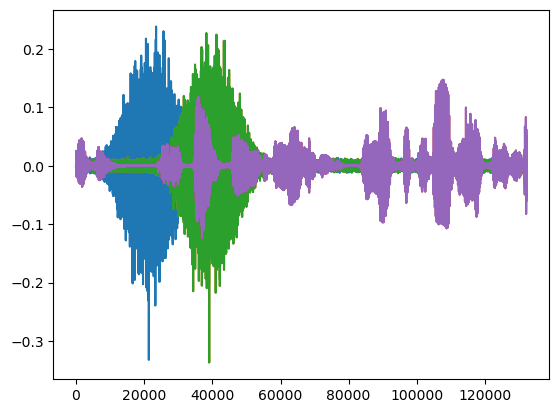

In [11]:
## Plot original and best distractor 
# center crop distractor 
# distractor_crop = crop_op(distractor)
plt.plot(distractor.cpu().numpy())
plt.plot(distractor_eg_fin.detach().cpu().numpy().squeeze().T);
plt.plot(fg.cpu().numpy().squeeze().T)

Target word is: second


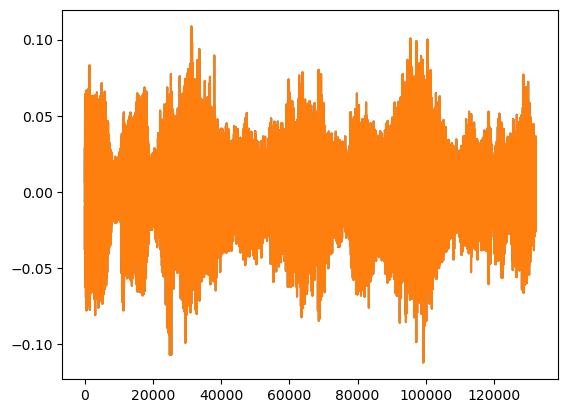

In [24]:
plt.plot(mixture_wav.squeeze().cpu().detach().numpy().T)
ipd.display(ipd.Audio(distractor_eg_fin.squeeze().cpu().detach().numpy(), rate=SAMPLERATE, normalize=False))
print(f"Target word is: {ix_to_word[label.item()]}")